Import Libraries such as Pandas, Datasets, Matplotlib.pyplot and Seaborn.

In [ ]:
import ast # For string conversion into list object
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt

plt.close('all')

import seaborn as sns

# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data Cleanup
# make datetime string into datetime object
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
# in column job_skills, make list from string into panda series (list) object using ast.literal_eval
df["job_skills"] = df["job_skills"].apply(lambda skill_list: ast.literal_eval(skill_list) if pd.notna(skill_list) else None)

Import FuncFormatter, so as to format x/y axis ticks as £K

In [ ]:
from matplotlib.ticker import FuncFormatter
def pounds_k(x, pos):
    return f"£{x/1000:.0f}K"

# Which companies are most hiring in the UK?

Filter the dataframe to show job postings from the United Kingdom whilst ensuring to create a copy of it also for data integrity.

In [3]:
df_UK = df[df["job_country"] == "United Kingdom"].copy()

Group the copied dataframe by column company_name and return the count of job postings using .size() method. Sort values by count in descending order.

In [4]:
df_companies = df_UK.groupby("company_name").size()

df_companies = df_companies.reset_index(name="count")

df_companies.sort_values(by="count", ascending=False, inplace=True)

df_companies

,company_name,count
3727,Harnham,1222
4480,Jobleads-UK,671
1856,ClickJobs.io,664
1598,CareerAddict,324
6954,RemoteWorker UK,270
...,...,...
9627,webmaster,1
9626,waters.com,1
32,4Front Recruitment Limited,1
30,3PL,1


Create a subset of data showing top 5 companies hiring for data jobs. Name this subset top_5_companies.

In [5]:
plt.close('all')

In [6]:
top_5_companies = df_companies.head(5)

Plot the subset using Seaborn

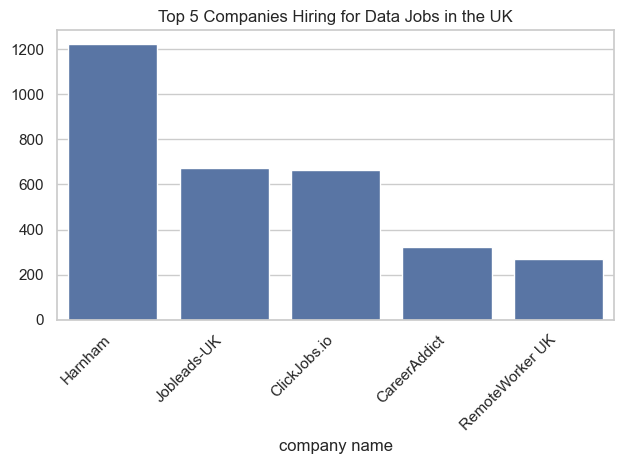

In [7]:
sns.set_theme(style="whitegrid")

sns.barplot(
    data=top_5_companies,
    x="company_name",
    y="count",
    legend=False,
);

plt.title("Top 5 Companies Hiring for Data Jobs in the UK")
plt.xlabel("company name")
plt.xticks(rotation=45, ha='right') # Rotate labels 45 degrees and align the text ends to the right
plt.ylabel("")
plt.tight_layout()

Now to calculate the percentage of jobs which are work from home, perform a value counts on the column job_work_from_home.
Assigning this to a dataframe called df_work_from_home. We reset the index to make it into a dataframe (we name this index 'count').
Next, I add a column called Total which sums up the values of False and True.
Then, I add a column called Percentage which calculates the percentage using the values from the columns Count and Total.

# What percentage of jobs are work from home?

In [8]:
df_work_from_home = df_UK.value_counts("job_work_from_home").reset_index(name="count")

df_work_from_home["total"] = df_work_from_home["count"].loc[0] + df_work_from_home["count"].loc[1]

df_work_from_home["percentage"] = (df_work_from_home["count"] / df_work_from_home["total"]) * 100

df_work_from_home

,job_work_from_home,count,total,percentage
0,False,36611,40375,90.677399
1,True,3764,40375,9.322601


Use Matplotlib to plot pie chart as Seaborn does not support pie charts.
Need to set index before plot because I need the labels to be column job_work_from_home.
Count column is the value of each label.

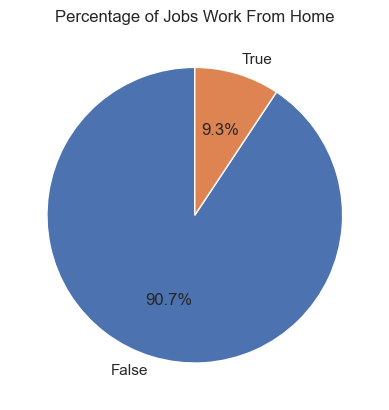

In [9]:
df_work_from_home.set_index("job_work_from_home")["count"].plot(
    kind="pie",
    startangle=90, # Avoid 'Pacman' look
    autopct="%1.1f%%" # for formatting percentage
)

plt.title("Percentage of Jobs Work From Home");

# What are the top 5 data jobs?

Aggregate count of jobs by job title using .value_counts() method. Values are sorted and a subset of top 5 jobs is created using the .head() method.

In [10]:
df_job_counts = df_UK.value_counts("job_title_short").sort_values(ascending=False).head().reset_index(name="count")

df_job_counts

,job_title_short,count
0,Data Engineer,11807
1,Data Analyst,10482
2,Data Scientist,9148
3,Senior Data Engineer,3337
4,Senior Data Scientist,2367


Plot the subset using Seaborn

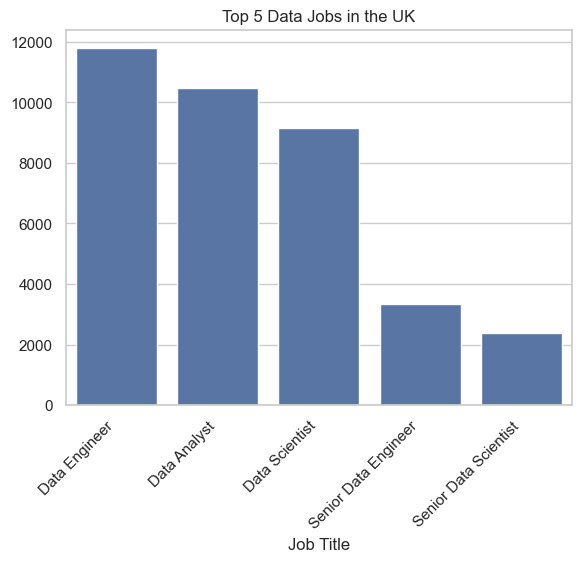

In [11]:
sns.barplot(
    data=df_job_counts,
    x="job_title_short",
    y="count",
)

plt.title("Top 5 Data Jobs in the UK")
plt.tight_layout()
plt.xlabel("Job Title")
plt.ylabel("")
plt.xticks(rotation=45, ha="right");


# What are the average salaries for data jobs?

Aggregate median salary data based on job titles using groupby() function. Values are sorted in descending order and then saved into a dataframe.

In [12]:
df_median_salaries = df_UK.groupby("job_title_short")["salary_year_avg"].median().sort_values(ascending=False)

df_median_salaries = df_median_salaries.reset_index(name="median_salary")

df_median_salaries

,job_title_short,median_salary
0,Senior Data Scientist,157500.0
1,Machine Learning Engineer,149653.0
2,Senior Data Engineer,147500.0
3,Senior Data Analyst,111175.0
4,Data Engineer,110000.0
5,Data Scientist,105300.0
6,Software Engineer,89100.0
7,Data Analyst,87750.0
8,Business Analyst,56700.0
9,Cloud Engineer,NaN


Target jobs are assigned to variable job_list. Above dataframe is filtered by these target jobs and assigned to variable df_median_salaries_filtered.

In [13]:
job_list = ["Data Analyst", "Data Engineer", "Data Scientist"]

df_median_salaries_filtered = df_median_salaries[df_median_salaries["job_title_short"].isin(job_list)]

Filtered dataframe df_median_salaries_filtered is plotted on a barplot using Seaborn

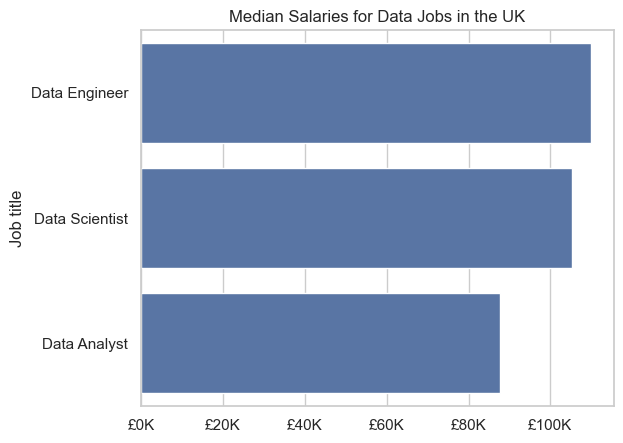

In [14]:
sns.barplot(
    data=df_median_salaries_filtered,
    y="job_title_short",
    x="median_salary"
);

plt.gca().xaxis.set_major_formatter(FuncFormatter(pounds_k)) # Format x axis ticks as £K

plt.title("Median Salaries for Data Jobs in the UK")
plt.tight_layout()
plt.xlabel("")
plt.ylabel("Job title");

# How many Data Jobs are Posted throughout the Year?

Dataframe df_UK is copied.

In [15]:
df_UK_copy = df_UK.copy()

A new column is added called job_posted_month which extracts month name from date object in column job_posted_date. Add a new index because it is inconsistent and give it a name.

In [16]:
df_UK_copy["job_posted_month"] = df_UK_copy["job_posted_date"].dt.strftime("%B")

df_UK_copy.reset_index(inplace=True)
df_UK_copy.index.name = "job_index"

df_UK_copy

,index,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,search_location,job_posted_date,job_no_degree_mention,job_health_insurance,job_country,salary_rate,salary_year_avg,salary_hour_avg,company_name,job_skills,job_type_skills,job_posted_month
job_index,,,,,,,,,,,,,,,,,,,
0,15,Data Engineer,Data Engineer,"Aberdeen, UK",via LinkedIn,Temp work,False,United Kingdom,2023-10-19 13:37:16,False,False,United Kingdom,NaN,NaN,NaN,Orion Group,"[python, sql, power bi]","{'analyst_tools': ['power bi'], 'programming':...",October
1,45,Senior Data Analyst,Senior Data Analyst,"Leeds, UK",via My Stateline Jobs,Full-time,False,United Kingdom,2023-05-30 13:14:08,True,False,United Kingdom,NaN,NaN,NaN,Corecom Consulting,"[sql, python]","{'programming': ['sql', 'python']}",May
2,74,Data Analyst,Data Entry/Economic Data Analyst,"Worcester, UK",via BeBee,Full-time,False,United Kingdom,2023-11-01 13:11:18,False,False,United Kingdom,NaN,NaN,NaN,ttgTalentSolutions,"[sql, r, python, tableau, power bi]","{'analyst_tools': ['tableau', 'power bi'], 'pr...",November
3,97,Data Analyst,"Systems & Data Analyst - Exploitation, Missing...",United Kingdom,via Totaljobs,Full-time and Contractor,False,United Kingdom,2023-12-04 13:14:01,True,False,United Kingdom,NaN,NaN,NaN,Solihull Metropolitan Borough Council,None,NaN,December
4,152,Data Scientist,Data Science Team Lead,Anywhere,via OnlyDataJobs,Full-time,True,United Kingdom,2023-12-23 13:12:16,False,False,United Kingdom,NaN,NaN,NaN,StepStone Group,"[react, docker]","{'libraries': ['react'], 'other': ['docker']}",December
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
40370,785485,Data Analyst,Data Quality Analyst,Anywhere,via LinkedIn,Full-time,True,United Kingdom,2023-10-04 06:09:44,False,False,United Kingdom,NaN,NaN,NaN,Viatris,"[sql, sql server, excel, powerpoint]","{'analyst_tools': ['excel', 'powerpoint'], 'da...",October
40371,785513,Data Scientist,Data Scientist,"Glasgow, UK",via Jobs Trabajo.org,Full-time,False,United Kingdom,2023-01-22 06:21:21,False,False,United Kingdom,NaN,NaN,NaN,ASA Recruitment,"[r, power bi]","{'analyst_tools': ['power bi'], 'programming':...",January
40372,785522,Data Engineer,Lead Data Engineer,"London, UK",via Jobs Trabajo.org,Full-time,False,United Kingdom,2023-01-19 06:16:45,True,False,United Kingdom,NaN,NaN,NaN,bionic-services-ltd,"[sql, python, sql server, aws, snowflake, ssis]","{'analyst_tools': ['ssis'], 'cloud': ['aws', '...",January


Pivot the data using pivot_table() method. This is to aggregate number of job postings posted each month for each job title. 

In [17]:
df_UK_pivot = df_UK_copy.pivot_table(
    index="job_posted_month",
    aggfunc="size",
    columns="job_title_short"
)

df_UK_pivot.reset_index(inplace=True) # Make the pivot table into dataframe

df_UK_pivot

job_title_short,job_posted_month,Business Analyst,Cloud Engineer,Data Analyst,Data Engineer,Data Scientist,Machine Learning Engineer,Senior Data Analyst,Senior Data Engineer,Senior Data Scientist,Software Engineer
0,April,29,7,561,611,519,8,63,155,123,18
1,August,22,7,610,863,657,15,96,247,181,13
2,December,124,31,712,1034,752,78,110,213,194,97
3,February,23,4,1051,1009,859,10,140,301,212,10
4,January,46,3,1467,1253,1142,8,169,347,326,20
5,July,38,5,892,960,646,13,116,321,184,12
6,June,14,2,736,862,636,3,102,292,154,4
7,March,47,5,712,789,699,8,91,224,179,19
8,May,23,1,614,645,486,11,60,227,153,16
9,November,155,39,840,1242,895,50,102,359,197,90


PROBLEM: column job_posted_month is ordered alphabetically so data in pivot table is ordered incorrectly.
SOLUTION: I need a separate month number column to order this job_posted_month by. This is similar to ordering months in Microsoft Power BI.
ACTION: I add a month_no column which generates a dummy date with the same month as column job_posted_month and
I use .dt.month to extract month number from this dummy date

In [18]:

df_UK_pivot["month_no"] = pd.to_datetime(df_UK_pivot["job_posted_month"], format="%B").dt.month

# Data is sorted by column month_no
df_UK_pivot.sort_values("month_no", inplace=True)

df_UK_pivot

job_title_short,job_posted_month,Business Analyst,Cloud Engineer,Data Analyst,Data Engineer,Data Scientist,Machine Learning Engineer,Senior Data Analyst,Senior Data Engineer,Senior Data Scientist,Software Engineer,month_no
4,January,46,3,1467,1253,1142,8,169,347,326,20,1
3,February,23,4,1051,1009,859,10,140,301,212,10,2
7,March,47,5,712,789,699,8,91,224,179,19,3
0,April,29,7,561,611,519,8,63,155,123,18,4
8,May,23,1,614,645,486,11,60,227,153,16,5
6,June,14,2,736,862,636,3,102,292,154,4,6
5,July,38,5,892,960,646,13,116,321,184,12,7
1,August,22,7,610,863,657,15,96,247,181,13,8
11,September,111,32,1112,1191,898,51,139,320,221,116,9
10,October,195,57,1175,1348,959,62,168,331,243,126,10


Now, I set column job_posted_month as a _renewed_ index and I drop column month_no as it is no longer required.

In [19]:
df_UK_pivot.set_index("job_posted_month", inplace=True)

df_UK_pivot.drop(columns="month_no", inplace=True)

df_UK_pivot

job_title_short,Business Analyst,Cloud Engineer,Data Analyst,Data Engineer,Data Scientist,Machine Learning Engineer,Senior Data Analyst,Senior Data Engineer,Senior Data Scientist,Software Engineer
job_posted_month,,,,,,,,,,
January,46,3,1467,1253,1142,8,169,347,326,20
February,23,4,1051,1009,859,10,140,301,212,10
March,47,5,712,789,699,8,91,224,179,19
April,29,7,561,611,519,8,63,155,123,18
May,23,1,614,645,486,11,60,227,153,16
June,14,2,736,862,636,3,102,292,154,4
July,38,5,892,960,646,13,116,321,184,12
August,22,7,610,863,657,15,96,247,181,13
September,111,32,1112,1191,898,51,139,320,221,116


I aggregate top 3 job titles with most job postings from the original dataframe and turn this into a list object. 

In [20]:
top_3_jobs = df_UK_copy["job_title_short"].value_counts().head(3)

# Change the index of value counts output to list
# Need to do this as only list can be passed through columns filter when plotting the line graph
top_3_jobs = top_3_jobs.index.to_list()

I then pass list of top 3 jobs into plot as a column filter and plot using Seaborn

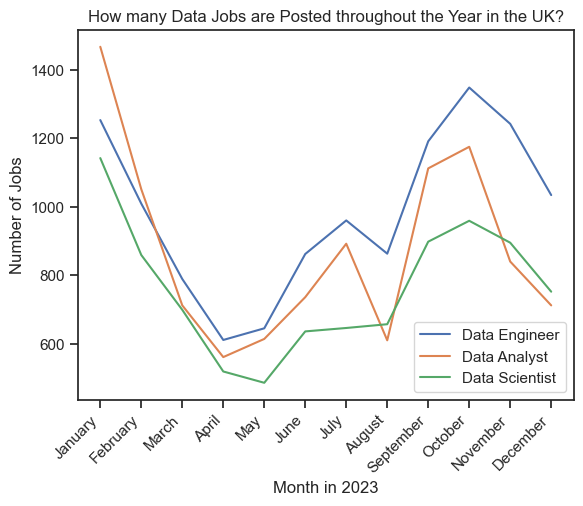

In [25]:
sns.set_theme(style="ticks")
sns.lineplot(
    data=df_UK_pivot[top_3_jobs],
    dashes=False
)

plt.title("How many Data Jobs are Posted throughout the Year in the UK?")
plt.legend() # Gives a proper legend
plt.xlabel("Month in 2023")
plt.ylabel("Number of Jobs")
plt.xticks(rotation=45, ha="right");